# IMPORT IMPORTANT LIBRARY AND LOADING DATASET

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/datasets/ranaghulamnabi/automobile-market-dataset-vehicle-specification/automobile_dataset.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/ranaghulamnabi/automobile-market-dataset-vehicle-specification/automobile_dataset.csv")

# STATISTICAL ANALYSIS

In [3]:
df.shape

(5500, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


In [5]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,4656.000000,5500.000000,4700.000000,4701.000000,5500.000000,4688.000000,4706.000000,5500.000000
mean,2014.494000,2.450623,114529.481636,198.236596,189.014678,2.464000,0.408063,34.179771,12319.873636
std,5.789745,0.843913,91858.943421,55.678165,56.631309,1.280022,0.491527,15.085473,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.000000,39112.000000,160.000000,151.000000,1.000000,0.000000,27.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,3.000000,172757.500000,231.000000,219.000000,3.000000,1.000000,37.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


In [6]:
df.nunique()

Make                  10
Model                 40
Year                  20
Fuel_Type              4
Transmission           2
Engine_Size           45
Mileage             5182
Horsepower           309
Torque               318
Owners                 5
Accident_History       2
Service_History        3
Color                  8
Body_Type              5
Drivetrain             4
Fuel_Efficiency       96
Location              10
Selling_Price       4037
dtype: int64

In [7]:
df.dtypes

Make                 object
Model                object
Year                  int64
Fuel_Type            object
Transmission         object
Engine_Size         float64
Mileage               int64
Horsepower          float64
Torque              float64
Owners                int64
Accident_History    float64
Service_History      object
Color                object
Body_Type            object
Drivetrain           object
Fuel_Efficiency     float64
Location             object
Selling_Price         int64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64

# HHANDLING MISSING VALUE

## handling missing value of category columns

In [10]:
cat_col=df.select_dtypes(include=["object","category"]).columns
for col in cat_col:
    mode_val=df[col].mode(dropna=True)
    if len(mode_val)>0:
        df[col]=df[col].fillna(mode_val.iloc[0])


## handling missing value of float type columsn

In [11]:
flot_col=df.select_dtypes(include=["float"]).columns
for col in flot_col:
    df[col]=df[col].fillna(df[col].median())

# OUTLIER DETECTION AND HANDLING

In [12]:
num_col=df.select_dtypes(include=["int64","float64"])
outlier=pd.DataFrame(index=df.index)
for col in num_col:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outlier[col]=(df[col]<lower)|(df[col]>upper)

print(outlier.sum().sort_values(ascending=False))

Fuel_Efficiency     408
Engine_Size         344
Torque              261
Horsepower          226
Selling_Price       144
Mileage              54
Year                  0
Accident_History      0
Owners                0
dtype: int64


In [13]:
# HANDLE OUTLIER
for col in num_col:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[col]=df[col].clip(lower,upper)


# CORRELATION OF NUMERIC COLUMNS WITH TARGET

In [14]:
target='Selling_Price'
corr=df.select_dtypes(include=["int","float"]).corrwith(df[target],method="pearson")
corr=corr.drop(target,errors="ignore").sort_values(key=abs,ascending=False)
print(corr)

Year                0.820781
Mileage            -0.703064
Owners             -0.684647
Accident_History   -0.353265
Fuel_Efficiency     0.069388
Torque              0.063970
Horsepower          0.061531
Engine_Size        -0.005139
dtype: float64


# EDA

## CORREALATION HEATMAP

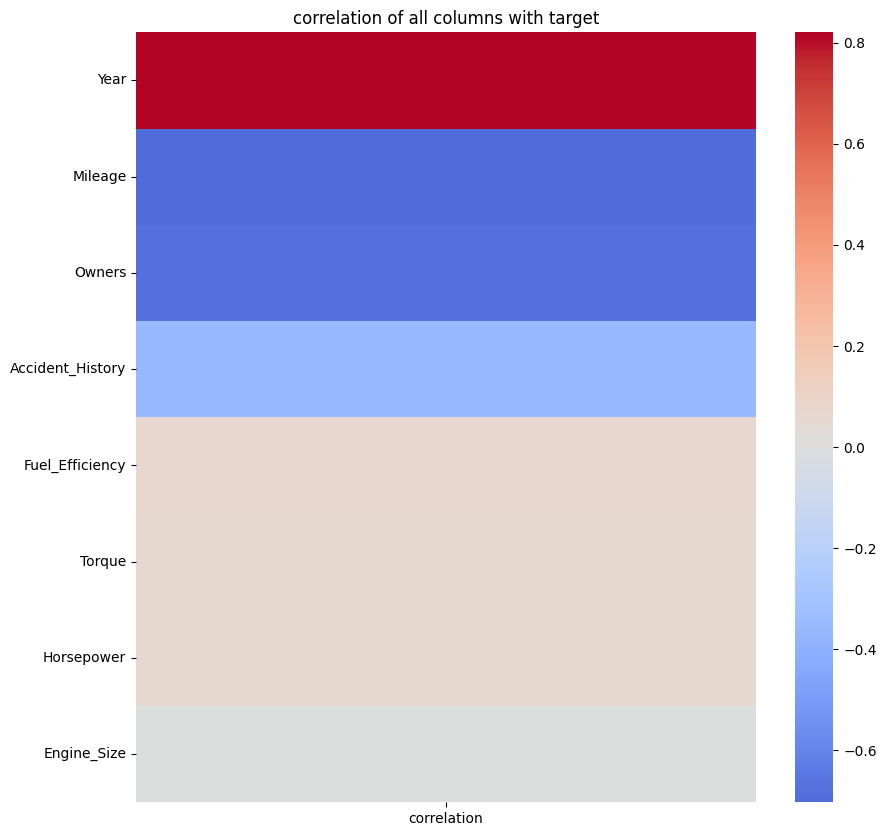

In [15]:
corr_df=corr.to_frame(name="correlation")
plt.figure(figsize=(10,10))
sns.heatmap(corr_df,annot=False,cmap="coolwarm",center=0)
plt.title("correlation of all columns with target")
plt.show()

## distribution of important columns 

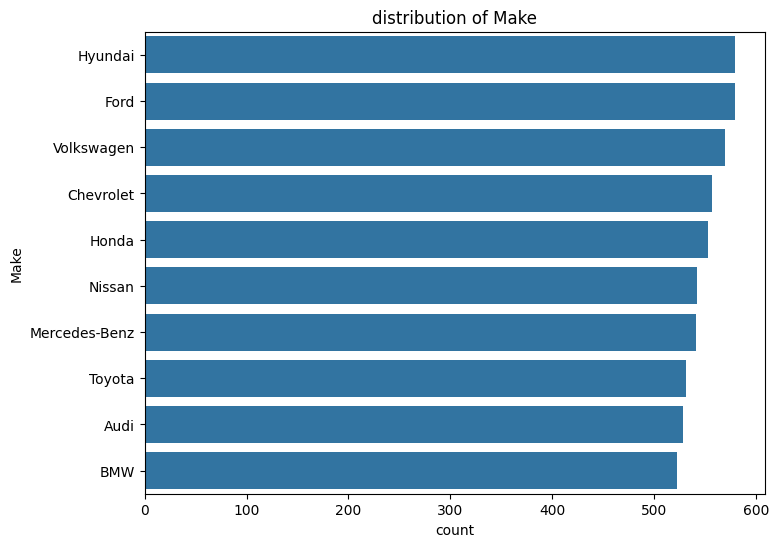

In [16]:
col='Make'
plt.figure(figsize=(8,6))
sns.countplot(data=df,y=col,order=df[col].value_counts().index)
plt.title("distribution of Make")
plt.show()

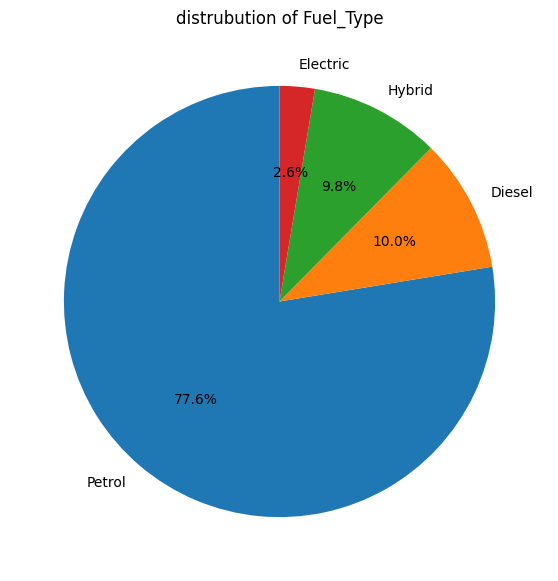

In [17]:
col='Fuel_Type'
count=df[col].value_counts()

plt.figure(figsize=(7,7))
plt.pie(count.values,labels=count.index,autopct="%1.1f%%",startangle=90)
plt.title("distrubution of Fuel_Type")
plt.show()

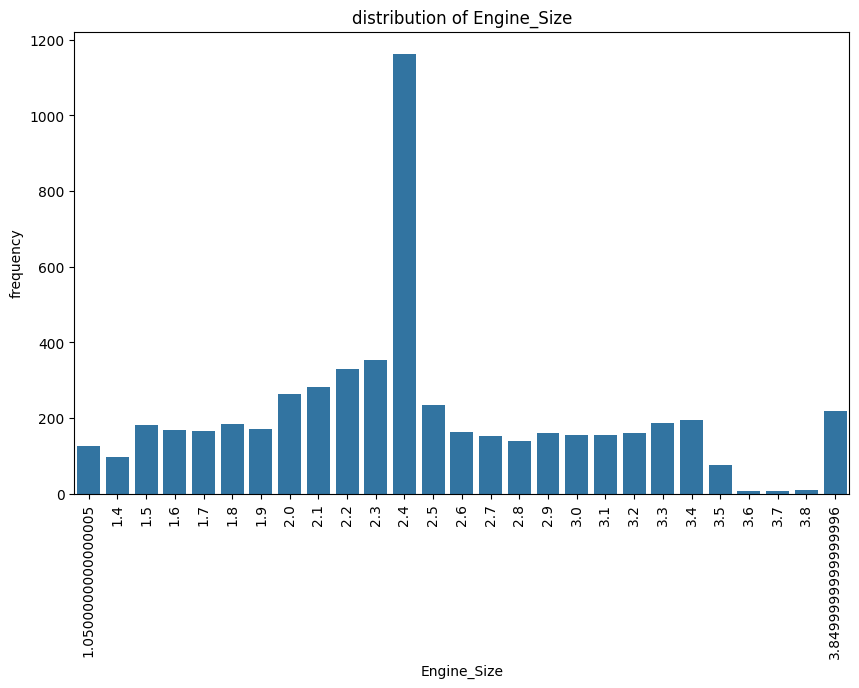

In [18]:
col='Engine_Size'
count=df[col].value_counts().sort_index()


plt.figure(figsize=(10,6))
sns.barplot(x=count.index.astype(float),y=count.values)
plt.title("distribution of Engine_Size")
plt.xticks(rotation=90)
plt.ylabel("frequency")

plt.show()


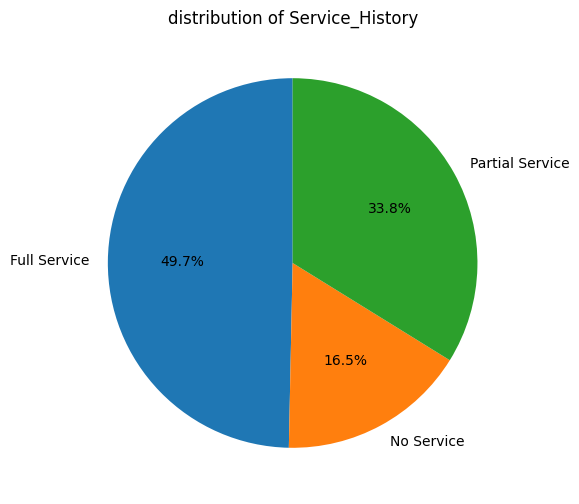

In [19]:
col='Service_History'
count=df[col].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(count.values,labels=count.index,autopct="%1.1f%%",startangle=90)
plt.title("distribution of Service_History")
plt.show()


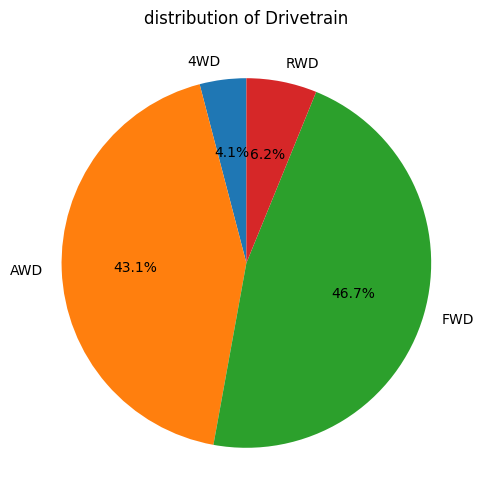

In [20]:
col='Drivetrain'
count=df[col].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(count.values,labels=count.index,autopct="%1.1f%%",startangle=90)
plt.title("distribution of Drivetrain")
plt.show()

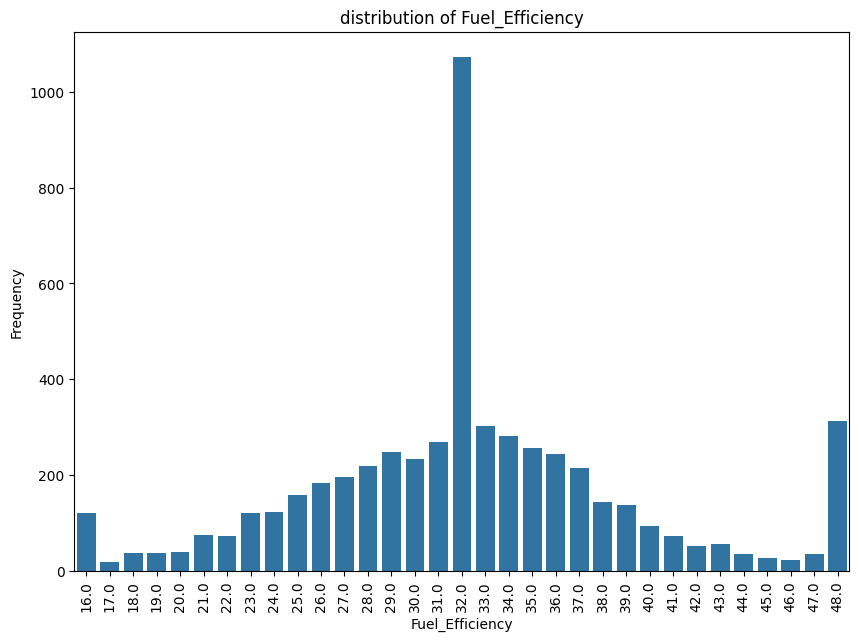

In [21]:
col='Fuel_Efficiency'
count=df[col].value_counts().sort_index()

plt.figure(figsize=(10,7))
sns.barplot(x=count.index.astype(float),y=count.values)
plt.title("distribution of Fuel_Efficiency")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      5500 non-null   object 
 5   Engine_Size       5500 non-null   float64
 6   Mileage           5500 non-null   float64
 7   Horsepower        5500 non-null   float64
 8   Torque            5500 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  5500 non-null   float64
 11  Service_History   5500 non-null   object 
 12  Color             5500 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   5500 non-null   float64
 16  Location          5500 non-null   object 


In [23]:
df.nunique()

Make                  10
Model                 40
Year                  20
Fuel_Type              4
Transmission           2
Engine_Size           27
Mileage             5129
Horsepower           213
Torque               213
Owners                 5
Accident_History       2
Service_History        3
Color                  8
Body_Type              5
Drivetrain             4
Fuel_Efficiency       33
Location              10
Selling_Price       3894
dtype: int64

In [24]:
df.head(50)

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.30,100.00,186.0,196.0,1,0.0,Full Service,Silver,SUV,AWD,30.0,IL,45786.625
1,Hyundai,Tucson,2008,Petrol,Automatic,2.30,373225.75,189.0,190.0,4,0.0,Full Service,Blue,SUV,FWD,35.0,FL,500.000
2,Volkswagen,Golf,2021,Hybrid,Automatic,1.90,46054.00,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429.000
3,Chevrolet,Tahoe,2005,Petrol,Automatic,2.20,141302.00,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,32.0,FL,2199.000
4,Toyota,Camry,2022,Petrol,Automatic,1.90,32813.00,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792.000
5,Chevrolet,Equinox,2008,Petrol,Automatic,2.70,60654.00,212.0,207.0,3,0.0,Full Service,Blue,SUV,AWD,25.0,TX,3421.000
6,Nissan,Sentra,2022,Petrol,Automatic,2.20,7444.00,187.0,180.0,1,0.0,Full Service,Gray,Sedan,AWD,34.0,IL,17145.000
7,Mercedes-Benz,C-Class,2022,Petrol,Automatic,2.30,32133.00,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,31416.000
8,BMW,X3,2023,Petrol,Automatic,2.40,1553.00,203.0,179.0,1,0.0,Full Service,Brown,SUV,AWD,25.0,FL,43914.000
9,Honda,Pilot,2020,Hybrid,Automatic,2.10,12494.00,178.0,168.0,1,0.0,No Service,Blue,SUV,FWD,44.0,NC,22311.000
